In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cmap import Colormap

DATA = Path("../data")
FIGS = Path("../figures")
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "legend.frameon": False,
    "font.family": "sans-serif",
})

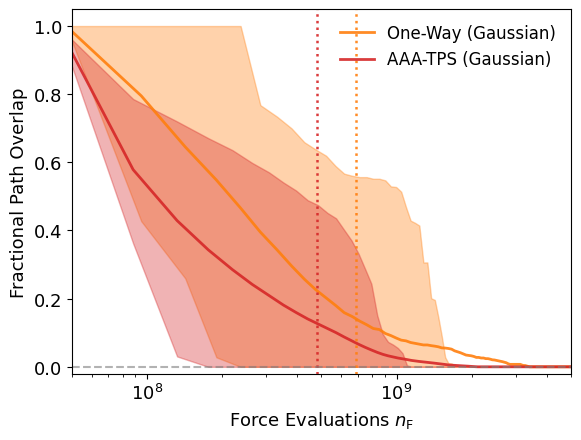

In [2]:
fig, ax = plt.subplots(figsize=(6, 4.6))

for tag, label, color in [("1wS", "One-Way (Gaussian)", "#ff7f0e"),
                          ("AA",  "AAA-TPS (Gaussian)", "#d62728")]:
    df = pd.read_csv(DATA / f"overlap_{tag}.csv")
    x = df["force_evaluations"]
    ax.plot(x, df["mean_overlap"], "-", color=color, alpha=0.9,
            label=label, lw=2)
    ax.fill_between(x, df["p10_overlap"], df["p90_overlap"],
                    color=color, alpha=0.35)

persist = pd.read_csv(DATA / "overlap_persistence.csv",
                      index_col=0)
ax.axvline(persist.loc["1wS", "avg_age_force_evals"],
           color="#ff7f0e", ls=":", lw=1.8, alpha=0.9)
ax.axvline(persist.loc["AA",  "avg_age_force_evals"],
           color="#d62728", ls=":", lw=1.8, alpha=0.9)

ax.axhline(0, color="gray", ls="--", alpha=0.6)
ax.set_xscale("log")
ax.set_xlim(5e7, 5e9)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel(r"Force Evaluations $n_\mathrm{F}$")
ax.set_ylabel("Fractional Path Overlap")
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIGS / "overlap.png", dpi=600)
plt.show()

/var/folders/9f/bc5b5g9j0392g_75d5_2zwp00000gn/T/ipykernel_22288/749702667.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y, s=1.5, c=colors_12[r], zorder=10)
/var/folders/9f/bc5b5g9j0392g_75d5_2zwp00000gn/T/ipykernel_22288/749702667.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x[acc],  y[acc],  s=1, c=colors_12[r], zorder=10)


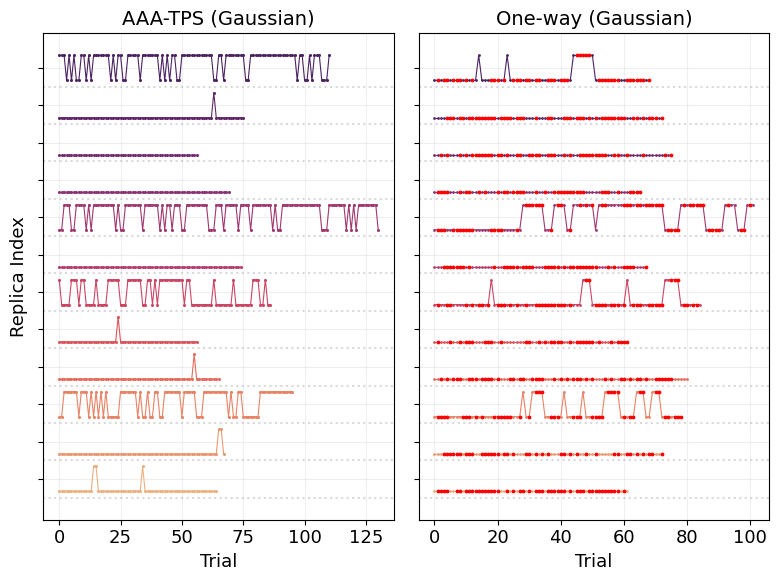

In [3]:
cm = Colormap("seaborn:flare").to_mpl().reversed()
colors_12 = cm(np.linspace(0, 1, 12))

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
spacing = 3

for ax, tag, title, use_mask in [
    (axes[0], "AA",  "AAA-TPS (Gaussian)", False),
    (axes[1], "1wS", "One-way (Gaussian)", True),
]:
    df = pd.read_csv(DATA / f"channels_{tag}.csv")
    yticks, ylabels = [], []
    cur_y = 0

    for r, group in df.groupby("replica"):
        x = group["trial"].values
        y = group["channel"].values + cur_y

        ax.plot(x, y, lw=0.8, c=colors_12[r])

        if use_mask:
            acc = group["accepted"].values.astype(bool)
            ax.scatter(x[acc],  y[acc],  s=1, c=colors_12[r], zorder=10)
            ax.scatter(x[~acc], y[~acc], s=3, c="red", zorder=10)
        else:
            ax.scatter(x, y, s=1.5, c=colors_12[r], zorder=10)

        yticks.append(cur_y)
        ylabels.append(str(r + 1))
        cur_y -= spacing
        ax.axhline(cur_y + spacing / 2, color="gray", ls=":", alpha=0.3)

    ax.set_title(title)
    ax.set_xlabel("Trial")
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels if ax is axes[0] else [])
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Replica Index")
fig.tight_layout()
fig.savefig(FIGS / "channel_switches.png", dpi=600)
plt.show()

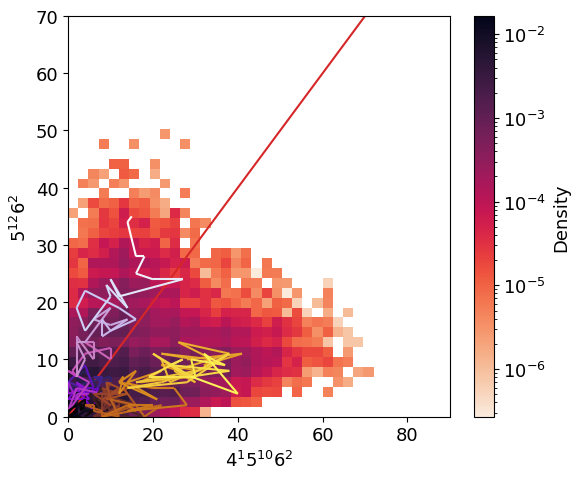

In [ ]:
from matplotlib.collections import LineCollection

hist  = pd.read_csv(DATA / "cage_points.csv")
diag  = pd.read_csv(DATA / "cage_diagonal.csv")

cm_rocket = Colormap("seaborn:rocket").to_mpl().reversed()
cm_gothic = Colormap("cmasher:gothic").to_mpl()
cm_amber  = Colormap("cmasher:amber").to_mpl()

fig, ax = plt.subplots(figsize=(6, 5))

counts, xedges, yedges = np.histogram2d(
    hist["cage_4151062"], hist["cage_51262"],
    bins=30, range=[[0, 72], [0, 52]], density=True,
)
X, Y = np.meshgrid(xedges, yedges, indexing="ij")
pc = ax.pcolormesh(X, Y, counts, cmap=cm_rocket, norm=mcolors.LogNorm())

for traj_id, cmap_name in [(5, cm_gothic), (11, cm_amber)]:
    df = pd.read_csv(DATA / f"cage_traj_{traj_id}.csv")
    pts = np.column_stack([df["cage_4151062"].values,
                           df["cage_51262"].values])
    segments = np.stack([pts[:-1], pts[1:]], axis=1)  # shape (N-1, 2, 2)

    lc = LineCollection(
        segments,
        cmap=cmap_name,
        linewidth=1.5,
        zorder=10,
    )
    lc.set_array(np.arange(len(segments)))  # gradient along time
    ax.add_collection(lc)

ax.plot(diag["diagonal"], diag["diagonal"], color="#d62728", lw=1.5)

ax.set_xlabel(r"$4^1 5^{10} 6^2$")
ax.set_ylabel(r"$5^{12} 6^2$")
ax.set_xlim(0, 90)
ax.set_ylim(0, 70)
fig.colorbar(pc, ax=ax, label="Density")

fig.tight_layout()
fig.savefig(FIGS / "cage_histogram.png", dpi=600)
plt.show()